In [25]:
import os
import warnings
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import pearsonr
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    KFold, LeaveOneOut, RandomizedSearchCV,
    StratifiedKFold, cross_val_predict, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

### Merging tables

In [26]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

## Tabela de Resultados

In [ ]:
csv_filename = 'eeg_ablation_results_ec.csv'

current_condition = 'Eyes Closed'
current_category = 'Somente Conectividade global em banda beta'
classifier_name = 'Linear SVM'

pasta_saida = 'features_extraidas_ec'
nome_arquivo_saida = 'features_conectividade_beta.csv' 

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"Tabela já existe. Registros atuais: {len(df_results)}")
else:
    columns = [
        'Feature_Category', 
        'Classifier', 
        'Condition', 
        'Num_Features', 
        'Accuracy', 
        'AUC_ROC', 
        'F1_Score'
    ]
    df_results = pd.DataFrame(columns=columns)
    print("Tabela criada com sucesso.")

Tabela já existe. Registros atuais: 12


In [28]:
bands = {
    'Delta': (0.1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 100)
}

X_features = []
y_labels = []
feature_names = []
patient_ids = []
eeg_folder = './cleaned_ec' 

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

### Extração das Features

In [ ]:
from scipy.signal import hilbert

# Lista para armazenar o biomarcador de cada paciente
biomarcadores_conectividade = []
patient_ids = []
y_labels = []

# Pasta do seu pré-processamento[cite: 5]
eeg_folder = './cleaned_ec' 

for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID']))
    pain_score = float(row['Actual Pain'])
    
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_ec-epo.fif")

    if os.path.exists(path):
        try:
            # 1. Carregar as épocas do paciente
            epochs = mne.read_epochs(path, preload=True, verbose=False)
            
            # 2. Filtrar os dados estritamente para a banda Beta (13 a 30 Hz)
            epochs_beta = epochs.copy().filter(l_freq=13.0, h_freq=30.0, verbose=False)
            
            # Formato dos dados: (épocas, canais, tempo)
            data_beta = epochs_beta.get_data()
            n_epochs, n_channels, n_times = data_beta.shape
            
            # 3. Calcular o envelope de amplitude usando a Transformada de Hilbert
            # O envelope é o valor absoluto do sinal analítico
            analytic_signal = hilbert(data_beta, axis=-1)
            amplitude_envelope = np.abs(analytic_signal)
            
            aec_epochs = []
            
            # 4. Calcular a matriz de correlação par a par para cada época
            for i in range(n_epochs):
                # np.corrcoef espera o formato (variáveis, observações) -> (canais, tempo)
                corr_matrix = np.corrcoef(amplitude_envelope[i])
                
                # 5. Extrair apenas o triângulo superior da matriz de conectividade
                # k=1 exclui a diagonal principal (correlação do canal com ele mesmo = 1)
                upper_triangle = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
                
                # Média das conexões da época
                aec_epochs.append(np.mean(upper_triangle))
            
            # 6. Média final da conectividade global em todas as épocas do paciente
            global_beta_connectivity = np.mean(aec_epochs)
            
            biomarcadores_conectividade.append({
                'Global_Beta_AEC': global_beta_connectivity
            })
            patient_ids.append(patient_id)
            y_labels.append(pain_score)
            
            print(f"Paciente {patient_id} | Conectividade Global Beta AEC: {global_beta_connectivity:.4f}")
            
        except Exception as e:
            print(f"Falha no paciente {patient_id}: {e}")

# Criar o DataFrame final para as análises estatísticas
df_aec = pd.DataFrame(biomarcadores_conectividade)
df_aec['patient_id'] = patient_ids
df_aec['pain_score'] = y_labels

display(df_aec.head())

# --- INÍCIO DO BLOCO: SALVAR CSV DA CONECTIVIDADE ---
os.makedirs(pasta_saida, exist_ok=True)
caminho_csv_aec = os.path.join(pasta_saida, 'features_conectividade_beta.csv')
df_aec.to_csv(caminho_csv_aec, index=False)

Paciente 0 | Conectividade Global Beta AEC: 0.0928
Paciente 1 | Conectividade Global Beta AEC: 0.0484
Paciente 2 | Conectividade Global Beta AEC: 0.1040
Paciente 3 | Conectividade Global Beta AEC: 0.0794
Paciente 4 | Conectividade Global Beta AEC: 0.0782
Paciente 5 | Conectividade Global Beta AEC: 0.1994
Paciente 6 | Conectividade Global Beta AEC: 0.1097
Paciente 7 | Conectividade Global Beta AEC: 0.1983
Paciente 8 | Conectividade Global Beta AEC: 0.1499
Paciente 9 | Conectividade Global Beta AEC: 0.1591
Paciente 10 | Conectividade Global Beta AEC: 0.1831
Paciente 11 | Conectividade Global Beta AEC: 0.1288
Paciente 13 | Conectividade Global Beta AEC: 0.1729
Paciente 15 | Conectividade Global Beta AEC: 0.1078
Paciente 16 | Conectividade Global Beta AEC: 0.0722
Paciente 18 | Conectividade Global Beta AEC: 0.2146
Paciente 19 | Conectividade Global Beta AEC: 0.0810
Paciente 20 | Conectividade Global Beta AEC: 0.1960
Paciente 21 | Conectividade Global Beta AEC: 0.1597
Paciente 22 | Conectiv

,Global_Beta_AEC,patient_id,pain_score
0,0.092836,0,7.0
1,0.048365,1,4.0
2,0.103982,2,3.0
3,0.079378,3,8.0
4,0.078185,4,5.0


### Treinamento SVM (LOO)


Avaliando Linear SVM (Somente Conectividade Global Beta) - class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 45.7%
LOO AUC-ROC: 0.092

Melhores hiperparâmetros: {'svm_final__C': 0.001}
-------------------------------------------------------

TOP 1 BIOMARCADORES (Linear SVM):
  1. Global_Beta_AEC: 100.0% de importância
-------------------------------------------------------

DIREÇÃO DOS TOP 1 BIOMARCADORES:
  1. Global_Beta_AEC: Coeficiente = -0.0001 (-)
     -> Uma conectividade maior DIMINUI a probabilidade matemática de Dor Severa (Classe 1).


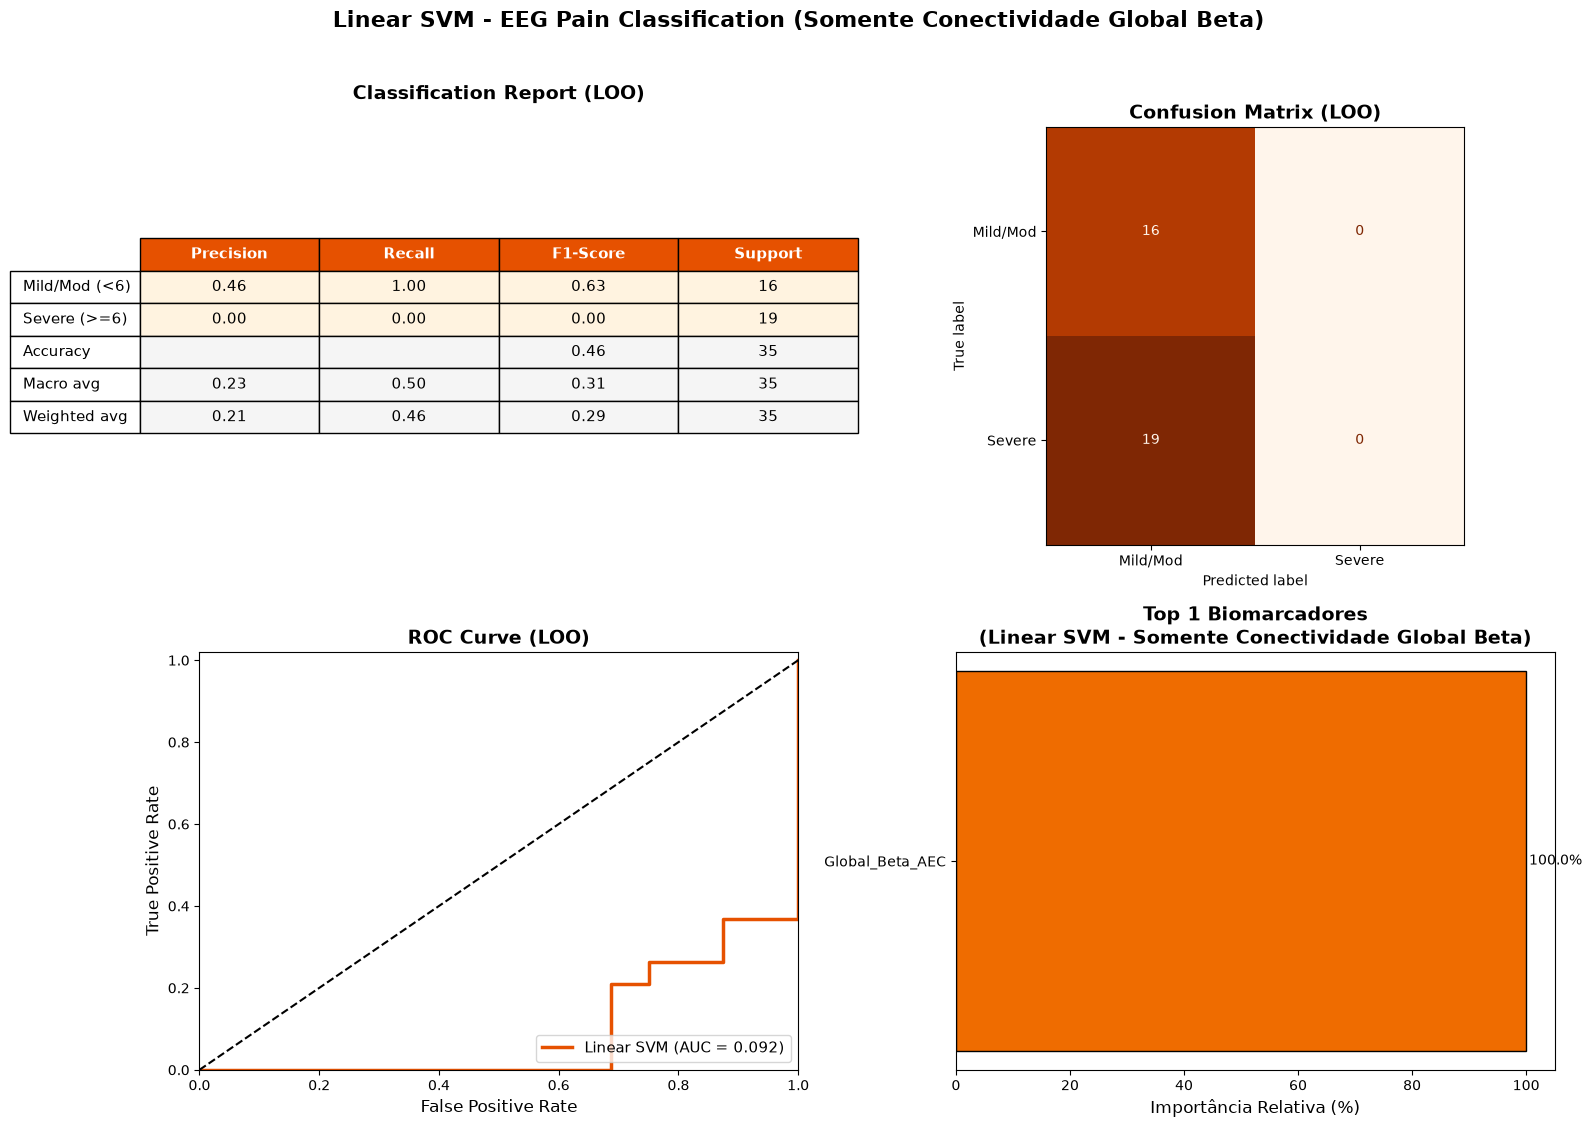


Gráfico salvo como: images\02_aec_beta_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [30]:
# 1. Definir os nomes das features extraindo APENAS a coluna de conectividade
feature_names = ['Global_Beta_AEC']
current_category = "Somente Conectividade Global Beta"

# 2. Criar a matriz X (features) e o vetor y (labels) a partir do df_aec (e não do df_biomarcadores)
X = df_aec[feature_names].values
y = df_aec['pain_score'].values

if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} ({current_category}) - class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    # Não precisamos de máscara pois só temos 1 feature global
    X_filtered = X
    feature_names_filt = np.array(feature_names)

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_top_features = 1 # Apenas 1 feature disponível

    # Pipeline base com SVM Linear (Sem RFE, pois há apenas 1 variável)
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")
    
    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    coef_originais = search.best_estimator_.named_steps['svm_final'].coef_[0]
    
    print('-' * 55)
    print(f"\nDIREÇÃO DOS TOP {num_top_features} BIOMARCADORES:")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        valor_coef = coef_originais[idx]
        sinal = "+" if valor_coef > 0 else "-"
        efeito = "AUMENTA" if valor_coef > 0 else "DIMINUI"
        
        print(f"  {i}. {feature_names_filt[idx]}: Coeficiente = {valor_coef:.4f} ({sinal})")
        print(f"     -> Uma conectividade maior {efeito} a probabilidade matemática de Dor Severa (Classe 1).")

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '02_aec_beta_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")